Bandgap is: 4.68790 eV
CBM is: 1.20480 eV
VBM is: -3.48310 eV
E-fermi is: -3.4831 eV


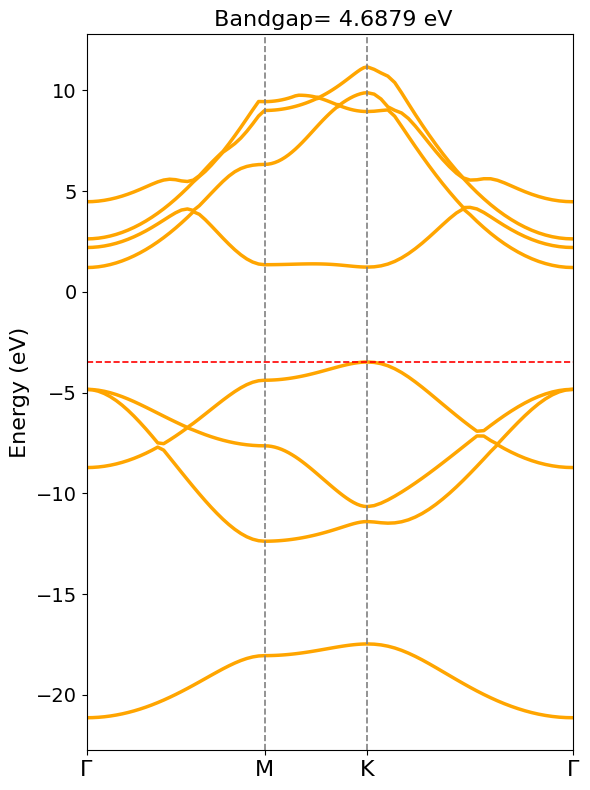

In [2]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline

#读取计算得到的能带数据
data=np.loadtxt('bands.dat.gnu')
energy = data[:, 1]
k_points = data[:, 0]

#画图的上下限
ymin=-5
ymax=15

k_label=[r'${\Gamma}$', 'M','K',r'${\Gamma}$']
k_density=30
occupied_band=4 #价带顶所在能带数
#nonsoc=（grep 'number of electrons' bands.out）/2
#soc=（grep 'number of electrons' bands.out）/2


num=np.where(k_points==0)[0][1]#每条能带的总k点数量
nbnd=int(np.shape(data)[0]/num)#number of bands

E=[]
k_path=k_points[:num]

for i in range(nbnd):
    temp=energy[i*num:(i+1)*num]
    E.append(temp)
    
E_fermi=max(E[occupied_band-1])#fermi energy
# E=E-E_fermi

gap=min(E[occupied_band])-max(E[occupied_band-1])#bandgap

k_vbm=([i for i, x in enumerate(E[occupied_band-1]) if x==max(E[occupied_band-1])])
k_cbm=([i for i, x in enumerate(E[occupied_band]) if x==min(E[occupied_band])])

plt.figure(figsize = (6,8))
for i in range(0,8):
    plt.plot(k_path,E[i],'orange',lw=2.5)
    #plt.scatter(k_path,E[i],lw=2.5,c='orange')
    
k_high=[]
for i in range(len(k_label)):
    k_high.append(k_path[k_density*i])
for i in range(1,len(k_label)-1):
    plt.axvline(x=k_high[i], ymin=0, ymax=1,linewidth=1.2,linestyle='--',color='gray')

plt.axhline(xmin=k_path[0],xmax=k_path[-1],y=max(E[occupied_band-1]),linewidth=1.2,linestyle='--',color='red')
plt.xlim([k_path[0],k_path[-1]])
# plt.ylim([5,30])
plt.tick_params(labelsize=14)
plt.ylabel(' Energy (eV) ',fontsize=16)
plt.title(' Bandgap= '+str(gap)[0:6]+' eV',fontsize=16)
plt.xticks( k_high, k_label ,fontsize=16)

plt.tight_layout()
plt.savefig('bands.png',dpi=600)
print('Bandgap is:','%.5f'% gap,'eV')
print('CBM is:','%.5f'% min(E[occupied_band]),'eV')
print('VBM is:','%.5f'% max(E[occupied_band-1]),'eV')
print('E-fermi is:',E_fermi,'eV')

In [23]:
def count_bands_in_energy_window(file_path, energy_min, energy_max):
    """
    自动解析文件，统计给定能量窗口内的能带数量。

    :param file_path: str, 文本文件路径
    :param energy_min: float, 能量窗口下限
    :param energy_max: float, 能量窗口上限
    :return: int, 能量窗口内的能带数量
    """
    with open(file_path, 'r') as file:
        lines = file.readlines()

    # 去掉空行，并按块分组
    blocks = []
    current_block = []
    for line in lines:
        if line.strip():  # 非空行
            current_block.append(line.strip())
        else:  # 遇到空行，存储当前块
            if current_block:
                blocks.append(current_block)
                current_block = []
    if current_block:  # 处理最后一个块
        blocks.append(current_block)

    # 计算 nk 和 nb
    nk = len(blocks[0]) if blocks else 0  # 每个块中的行数
    nb = len(blocks)  # 块的数量

    print(f"文件解析完成：nk = {nk}, nb = {nb}")

    # 统计能量窗口内的能带数量
    bands_in_window = 0
    for block in blocks:
        for line in block:
            _, energy = map(float, line.split())
            if energy_min <= energy <= energy_max:
                bands_in_window += 1
                break  # 一个能带只需满足一次条件即可

    return bands_in_window


file_path = "bands.dat.gnu"  
# file_path = "pwscf_band.dat"
energy_min =  -4.8
energy_max =  2.1

result = count_bands_in_energy_window(file_path, energy_min, energy_max)
print(f"能量窗口 [{energy_min}, {energy_max}] 内的能带数量是: {result}")

文件解析完成：nk = 91, nb = 8
能量窗口 [-4.8, 2.1] 内的能带数量是: 2


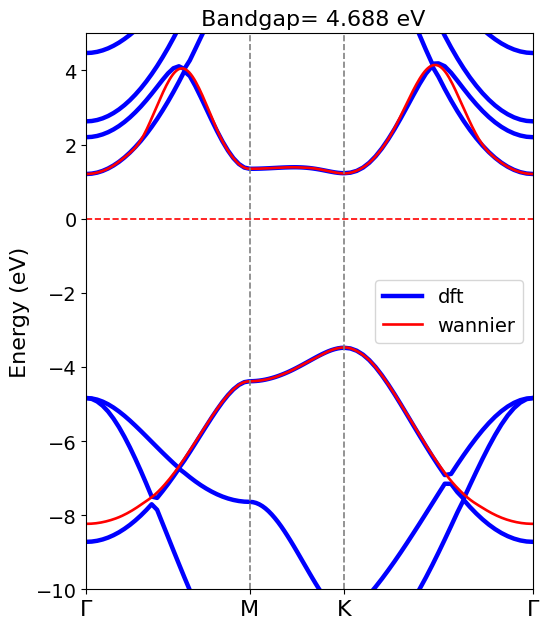

Bandgap is: 4.68790 eV
CBM is: 1.20480 eV
VBM is: -3.48310 eV
E-fermi is: -3.4831 eV


In [5]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline

data=np.loadtxt('bands.dat.gnu')
energy = data[:, 1]
k_points = data[:, 0]*2*np.pi/2.505754


k_label=[r'${\Gamma}$', 'M','K',r'${\Gamma}$']
k_density=30
occupied_band=4
#nonsoc=（grep 'number of electrons' bands.out）/2
#soc=（grep 'number of electrons' bands.out）/2

num = 91
nbnd= 8

E=[]
k_path=k_points[:num]

for i in range(nbnd):
    temp=energy[i*num:(i+1)*num]
    E.append(temp)
    
E_fermi=max(E[occupied_band-1])#fermi energy
# E=E-E_fermi

gap=min(E[occupied_band])-max(E[occupied_band-1])#bandgap

vbm = max(E[occupied_band-1])
cbm = min(E[occupied_band])

# k_vbm=([i for i, x in enumerate(E[occupied_band-1]) if x==max(E[occupied_band-1])])
# k_cbm=([i for i, x in enumerate(E[occupied_band]) if x==min(E[occupied_band])])

plt.figure(figsize = (5.6,6.4))
for i in range(nbnd):
    plt.plot(k_path,E[i],'blue',lw=3.2)
    #plt.scatter(k_path,E[i],lw=2.5,c='orange')
plt.plot(k_path,E[0],'blue',lw=3.2,label='dft')
####################################################################################
data_wan=np.loadtxt('pwscf_band.dat')
energy_wan = data_wan[:, 1]
k_points_wan = data_wan[:, 0]

num_wan = 274
nbnd_wan= 2

E_wan=[]
k_path_wan=k_points_wan[:num_wan]

for i in range(nbnd_wan):
    temp_wan=energy_wan[i*num_wan:(i+1)*num_wan]
    E_wan.append(temp_wan)

for i in range(1,nbnd_wan):
    plt.plot(k_path_wan,E_wan[i],'red',lw=1.9,linestyle='-')
    #plt.scatter(k_path,E[i],lw=2.5,c='orange')
plt.plot(k_path_wan,E_wan[0],'red',lw=1.9,linestyle='-',label='wannier')
####################################################################################
k_high=[]
for i in range(len(k_label)):
    k_high.append(k_path[k_density*i])
for i in range(1,len(k_label)-1):
    plt.axvline(x=k_high[i], ymin=0, ymax=1,linewidth=1.2,linestyle='--',color='gray')

plt.axhline(xmin=k_path[0],xmax=k_path[-1],y=0.0,linewidth=1.2,linestyle='--',color='red')
plt.xlim([k_path[0],k_path[-1]])
# plt.ylim([vbm-4,cbm+4])
plt.ylim([-10,5])
plt.tick_params(labelsize=14)
plt.ylabel(' Energy (eV) ',fontsize=16)
plt.title(' Bandgap= '+'%.3f'% gap+' eV',fontsize=16)
plt.xticks( k_high, k_label ,fontsize=16)
plt.legend(fontsize=14,loc='center right')
plt.tight_layout()
# plt.grid()
plt.savefig('bands.png',dpi=600)
plt.show()
print('Bandgap is:','%.5f'% gap,'eV')
print('CBM is:','%.5f'% cbm,'eV')
print('VBM is:','%.5f'% vbm,'eV')
print('E-fermi is:',E_fermi,'eV')